### IMPORT

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

raw_data = pd.read_csv('../data/employee_attrition_2026_master.csv')


### Checking Missing / Duplicate / raw_data Type

In [52]:
raw_data.head()

,employee_id,age,generation,gender,department,job_level,is_manager,tenure_years,salary_usd,salary_vs_market_pct,...,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition_reason,attrition
0,EMP000000,26,Gen Z,Female,Marketing,Junior,0,5.5,70000,5.2,...,3.6,2,0,62,0,2,0,22,stayed,0
1,EMP000001,35,Millennial,Female,Sales,Junior,0,0.5,64000,-15.5,...,4.8,3,2,79,1,2,0,24,stayed,0
2,EMP000002,23,Gen Z,Male,HR,Senior,0,2.0,142000,-15.9,...,10.0,1,2,43,0,4,1,3,poor_management,1
3,EMP000003,20,Gen Z,Female,Sales,Manager,1,2.2,147000,2.6,...,4.3,1,4,64,1,3,0,24,stayed,0
4,EMP000004,40,Millennial,Female,Data,Senior,0,6.0,141000,11.3,...,2.9,1,1,92,0,2,0,5,stayed,0


In [53]:
raw_data.info()

print(f"duplicated = {raw_data.duplicated().sum()}")
print(f"size = {raw_data.size}")
print(f"shape = {raw_data.shape}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 45000 non-null  object 
 1   age                         45000 non-null  int64  
 2   generation                  45000 non-null  object 
 3   gender                      45000 non-null  object 
 4   department                  45000 non-null  object 
 5   job_level                   45000 non-null  object 
 6   is_manager                  45000 non-null  int64  
 7   tenure_years                45000 non-null  float64
 8   salary_usd                  45000 non-null  int64  
 9   salary_vs_market_pct        45000 non-null  float64
 10  work_arrangement            45000 non-null  object 
 11  rto_mandate                 45000 non-null  int64  
 12  days_in_office_required     45000 non-null  int64  
 13  commute_minutes             450

### Claening

* Drop columns
    * employee_id ตัวชี้วัดไม่ได้ใช้  
    * attrition_reason ไม่เกี่ยวกับการคำนวณ   
    * is_manager ซ้ำซ้อนกับ job_level   
    * generation ตัวแปรอิสระสัมพันธ์กันเองสูงเกินไปกับ *age*  
*  กรองข้อมูลผิดปกติที่ 
    * อายุการทำงาน และอายุ ไม่สมเหตุสผลกัน ตัวอย่าง : age 20, tenure 9.8 years = เริ่มทำงานที่อายุ 10.2 ปี จึงทำการกรองข้อมูลออก
* นับจำนวน
    * จำนวนแถวทั้งหมด = 45,000 row
    * ถูกคัดกรองออกจำนวน 1,561 row จากเงื่อนไขอายุเริ่มทำงานต้องไม่ต่ำกว่า 20 ปี  
    คิดเป็น 3.469 % จากข้อมูลทั้งหมด

In [54]:
# Drop columns
raw_data = raw_data.drop(columns=["employee_id", "attrition_reason", "is_manager", "generation"])

# กรองข้อมูลผิดปกติที่ อายุการทำงาน และอายุ ไม่สมเหตุสผลกัน
bad_mask = raw_data["tenure_years"] > (raw_data["age"] - 16)
n_bad = bad_mask.sum()

# check removed rows
print(f"rows to remove = {n_bad} \n45,000-1,561 = {45000-n_bad} \nคิดเป็น = {(n_bad/45000)*100:.3f} % ")

clean_data = raw_data[~bad_mask].reset_index(drop=True)

rows to remove = 1561 
45,000-1,561 = 43439 
คิดเป็น = 3.469 % 


### Outlier

In [55]:
# 1. เช็ค outlier ปกติทางสถิติด้วย IQR (continuous columns only)
cols = ["age", "tenure_years", "salary_usd", "commute_minutes", "weekly_hours"]

for col in cols:
    q1 = clean_data[col].quantile(0.25)
    q3 = clean_data[col].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    
    outliers = ~clean_data[col].between(lo, hi)
    n_outliers = outliers.sum()
    print(f"{col:16s} bounds=({lo:.1f}, {hi:.1f}) min={clean_data[col].min()} max={clean_data[col].max()}")

# 2. เช็ค work_arrangement vs days_in_office_required
print("\nwork_arrangement vs days_in_office_required:")
print(pd.crosstab(clean_data["work_arrangement"], clean_data["days_in_office_required"]))

# 3. เช็คช่วงเงินเดือนแยกตาม job level
print("\nSalary range by job level:")
print(clean_data.groupby("job_level")["salary_usd"].agg(["min", "max"]))

# 4. ค้นหาข้อมูลเงินเดือนที่ผิดปกติ
salary_z = clean_data.groupby("job_level")["salary_usd"].transform(lambda s: (s - s.mean()) / s.std())
print(f"\nSalary outliers inside own job level (|z| > 3): {(salary_z.abs() > 3).sum()}")



age              bounds=(12.5, 56.5) min=20 max=64
tenure_years     bounds=(-2.6, 8.9) min=0.1 max=22.7
salary_usd       bounds=(-31500.0, 252500.0) min=35000 max=345000
commute_minutes  bounds=(-29.5, 94.5) min=0 max=180
weekly_hours     bounds=(23.0, 63.0) min=30 max=71

work_arrangement vs days_in_office_required:
days_in_office_required     0     1     2     3     4     5
work_arrangement                                           
hybrid                      0     0  5631  7804  4177  2025
onsite                      0     0     0     0  3367  8368
remote                   3493  4830  2518  1226     0     0

Salary range by job level:
              min     max
job_level                
Director   118000  345000
Junior      35000   95000
Lead        80000  242000
Manager     88000  268000
Mid         44000  146000
Senior      60000  203000

Salary outliers inside own job level (|z| > 3): 116


In [56]:
# Log transform: shrink long tail, keep order, keep all rows
clean_data["tenure_years"] = np.log1p(clean_data["tenure_years"])
clean_data["commute_minutes"] = np.log1p(clean_data["commute_minutes"])

# Salary compared with own job level
# คำนวณ Median ตามระดับงาน แล้วสร้างคอลัมน์ใหม่
level_median = clean_data.groupby("job_level")["salary_usd"].transform("median")
clean_data["salary_vs_level"] = clean_data["salary_usd"] / level_median

print(f"Done, shape: {clean_data.shape}\n")
print(clean_data[["tenure_years", "commute_minutes", "salary_vs_level"]].describe().loc[["min", "max"]])


Done, shape: (43439, 26)

     tenure_years  commute_minutes  salary_vs_level
min      0.095310         0.000000         0.461538
max      3.165475         5.198497         1.586957


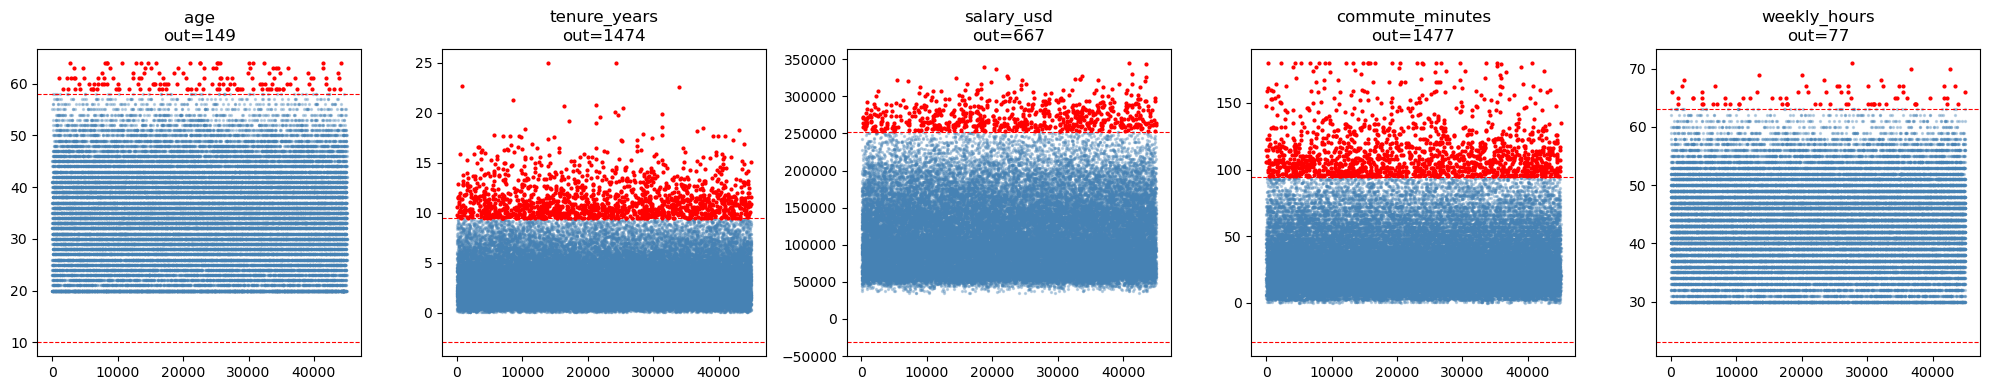

In [57]:
raw_outlier = raw_data.copy()
fig, axes = plt.subplots(1, len(cols), figsize=(20, 4))
for ax, col in zip(axes, cols):
    s = raw_outlier[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    is_out = ~s.between(lo, hi)
    ax.scatter(s.index[~is_out], s[~is_out], s=2, alpha=0.3, color="steelblue")
    ax.scatter(s.index[is_out], s[is_out], s=4, color="red")
    ax.axhline(lo, color="red", ls="--", lw=0.8)
    ax.axhline(hi, color="red", ls="--", lw=0.8)
    ax.set_title(f"{col}\nout={is_out.sum()}")
plt.tight_layout()
plt.show()


ในการตรวจสอบ outlier พบค่าผิดปกติในหลายตัวแปร เช่น tenure, commute และ salary แต่ไม่ได้ลบ outlier 
ออกทันที จึงตรวจสอบความสมเหตุสมผลก่อน และเลือกเก็บข้อมูลที่ยังมีความเป็นไปได้จริงไว้

เพราะ outlier อาจเป็น ข้อมูลจริง เช่น
คนทำงานมานานมาก
เงินเดือนสูง
เดินทางไกล
ทำงานหลายชั่วโมง

In [58]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43439 entries, 0 to 43438
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         43439 non-null  int64  
 1   gender                      43439 non-null  object 
 2   department                  43439 non-null  object 
 3   job_level                   43439 non-null  object 
 4   tenure_years                43439 non-null  float64
 5   salary_usd                  43439 non-null  int64  
 6   salary_vs_market_pct        43439 non-null  float64
 7   work_arrangement            43439 non-null  object 
 8   rto_mandate                 43439 non-null  int64  
 9   days_in_office_required     43439 non-null  int64  
 10  commute_minutes             43439 non-null  float64
 11  prefers_remote              43439 non-null  int64  
 12  flexibility_importance      43439 non-null  int64  
 13  ai_tools_adoption           434

# encoding

|  | Column | Encoding Method | Reason |
| :--- | :--- | :--- | :--- |
| 1 | job_level | OrdinalEncoder | Has order rank : Junior < Mid < Senior < Lead < Manager < Director |
| 2 | ai_tools_adoption | OrdinalEncoder | Has natural rank : none < light < regular < power |
| 3 | gender | OneHotEncoder | Nominal, no order prevents the model from assuming mathematical ranking|
| 4 | department | OneHotEncoder | Nominal, no order prevents the model from assuming mathematical ranking|
| 5 | work_arrangement | OneHotEncoder | Nominal, no order prevents the model from assuming mathematical ranking|

In [59]:
# Ordinal encoding
job_level_order = ["Junior", "Mid", "Senior", "Lead", "Manager", "Director"]
clean_data["job_level"] = pd.Categorical(clean_data["job_level"], categories=job_level_order, ordered=True).codes
assert (clean_data["job_level"] >= 0).all()   # -1 = value not in list
clean_data["job_level"].value_counts().sort_index()

job_level
0    10418
1    13001
2     9508
3     4452
4     4361
5     1699
Name: count, dtype: int64

In [60]:
# Ordinal encoding
ai_order = ["none", "light", "regular", "power"]
clean_data["ai_tools_adoption"] = pd.Categorical(clean_data["ai_tools_adoption"], categories=ai_order, ordered=True).codes
assert (clean_data["ai_tools_adoption"] >= 0).all()   # -1 = value not in list
clean_data["ai_tools_adoption"].value_counts().sort_index()

ai_tools_adoption
0     7846
1    14747
2    14779
3     6067
Name: count, dtype: int64

In [61]:
# One-hot encoding
nominal_cols = ["gender", "department", "work_arrangement"]
clean_data = pd.get_dummies(clean_data, columns=nominal_cols, drop_first=False, dtype=int)

In [62]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43439 entries, 0 to 43438
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          43439 non-null  int64  
 1   job_level                    43439 non-null  int8   
 2   tenure_years                 43439 non-null  float64
 3   salary_usd                   43439 non-null  int64  
 4   salary_vs_market_pct         43439 non-null  float64
 5   rto_mandate                  43439 non-null  int64  
 6   days_in_office_required      43439 non-null  int64  
 7   commute_minutes              43439 non-null  float64
 8   prefers_remote               43439 non-null  int64  
 9   flexibility_importance       43439 non-null  int64  
 10  ai_tools_adoption            43439 non-null  int8   
 11  weekly_hours                 43439 non-null  int64  
 12  after_hours_work             43439 non-null  int64  
 13  burnout_score   

## Summary
---
### Data Preprocessing Summary
* **Initial Data** : 45,000 rows, 29 columns
* **Cleaned Data** : 43,439 rows, 38 columns

#### 1. Data Cleaning
* **Dropped Columns** 
  * employee_id
  * attrition_reason
  * is_manager 
  * generation
* **Logic Error Removed** 
  * records where tenure_years > (age - 16) (1,561 rows)  
* **Outlier Handling** :
  * tenure_years, commute_minutes → np.log1p (no row removed, no clip)
  * salary_usd → replaced by salary_vs_level (salary ÷ median of own job level)
  * age, weekly_hours → kept (values possible)

#### 2. Feature Encoding
* **Ordinal Encoding** :
  * job_level : Junior < Mid < Senior < Lead < Manager < Director
  * ai_tools_adoption : none < light < regular < power
* **One-Hot Encoding** : 
  * gender
  * department
  * work_arrangement

In [63]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43439 entries, 0 to 43438
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          43439 non-null  int64  
 1   job_level                    43439 non-null  int8   
 2   tenure_years                 43439 non-null  float64
 3   salary_usd                   43439 non-null  int64  
 4   salary_vs_market_pct         43439 non-null  float64
 5   rto_mandate                  43439 non-null  int64  
 6   days_in_office_required      43439 non-null  int64  
 7   commute_minutes              43439 non-null  float64
 8   prefers_remote               43439 non-null  int64  
 9   flexibility_importance       43439 non-null  int64  
 10  ai_tools_adoption            43439 non-null  int8   
 11  weekly_hours                 43439 non-null  int64  
 12  after_hours_work             43439 non-null  int64  
 13  burnout_score   

In [64]:
# clean_data.to_csv("data_preprocess.csv", index=False)